In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('data.csv')

df.head()

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight
0,1,7,16,1977,2,NL,M,32.0,NaN
1,2,7,16,1977,3,NL,M,33.0,NaN
2,3,7,16,1977,2,DM,F,37.0,NaN
3,4,7,16,1977,7,DM,M,36.0,NaN
4,5,7,16,1977,3,DM,M,35.0,NaN


In [5]:
## Dataset Overview

In [6]:
df.shape

(35549, 9)

In [7]:
df.describe()

,record_id,month,day,year,plot_id,hindfoot_length,weight
count,35549.000000,35549.000000,35549.000000,35549.000000,35549.000000,31438.000000,32283.000000
mean,17775.000000,6.474022,16.105966,1990.475231,11.397001,29.287932,42.672428
std,10262.256696,3.396583,8.256691,7.493355,6.799406,9.564759,36.631259
min,1.000000,1.000000,1.000000,1977.000000,1.000000,2.000000,4.000000
25%,8888.000000,4.000000,9.000000,1984.000000,5.000000,21.000000,20.000000
50%,17775.000000,6.000000,16.000000,1990.000000,11.000000,32.000000,37.000000
75%,26662.000000,9.000000,23.000000,1997.000000,17.000000,36.000000,48.000000
max,35549.000000,12.000000,31.000000,2002.000000,24.000000,70.000000,280.000000


In [8]:
df.dtypes

record_id            int64
month                int64
day                  int64
year                 int64
plot_id              int64
species_id          object
sex                 object
hindfoot_length    float64
weight             float64
dtype: object

In [9]:
## Missing Value Analysis

In [10]:
df.isnull().sum()

record_id             0
month                 0
day                   0
year                  0
plot_id               0
species_id          763
sex                2511
hindfoot_length    4111
weight             3266
dtype: int64

In [11]:
## Species Distribution

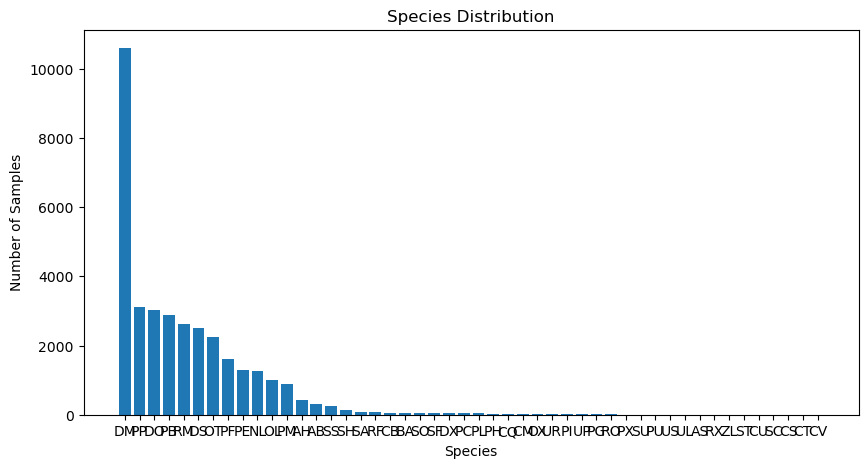

In [18]:
species_count = df['species_id'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(species_count.index, species_count.values)

plt.xlabel('Species')
plt.ylabel('Number of Samples')
plt.title('Species Distribution')
plt.savefig('./images/species_distribution.png')

plt.show()

In [13]:
## Average Weight Across Sites

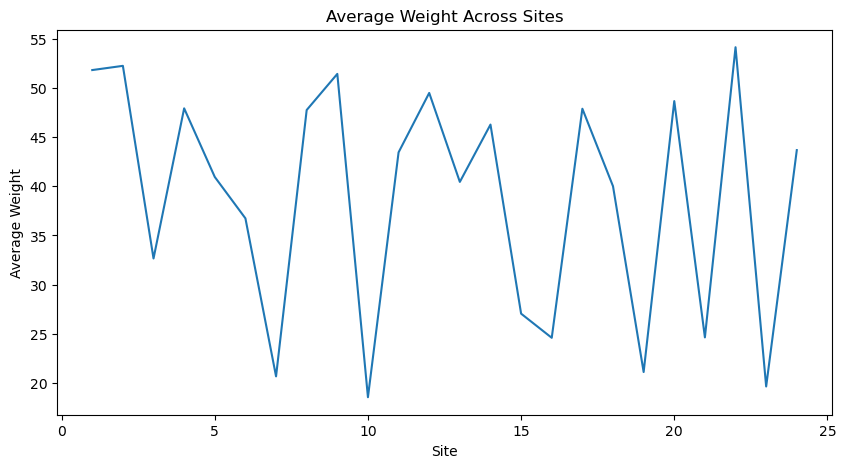

In [19]:
site_weight_mean = df.groupby('plot_id')['weight'].mean()

plt.figure(figsize=(10,5))
plt.plot(site_weight_mean.index, site_weight_mean.values)

plt.xlabel('Site')
plt.ylabel('Average Weight')
plt.title('Average Weight Across Sites')
plt.savefig('./images/weight_across_sites.png')


plt.show()

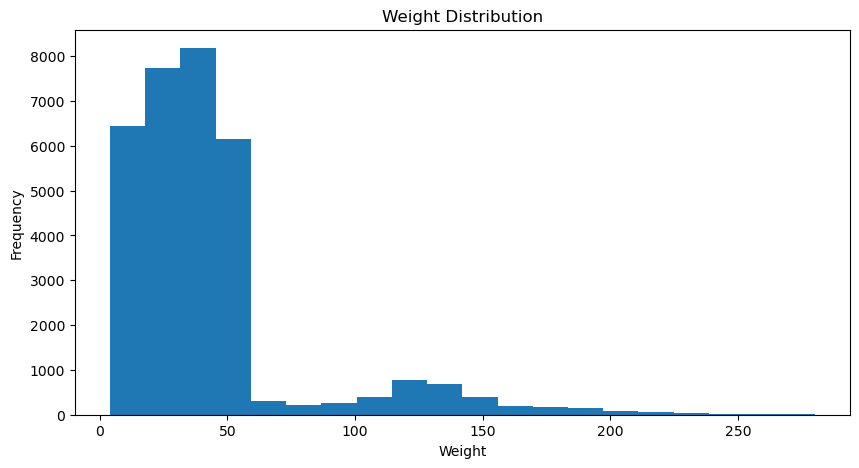

In [20]:
# Weight Distribution Histogram
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(df['weight'].dropna(), bins=20)

plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title('Weight Distribution')

plt.savefig('./images/weight_distribution.png')

plt.show()

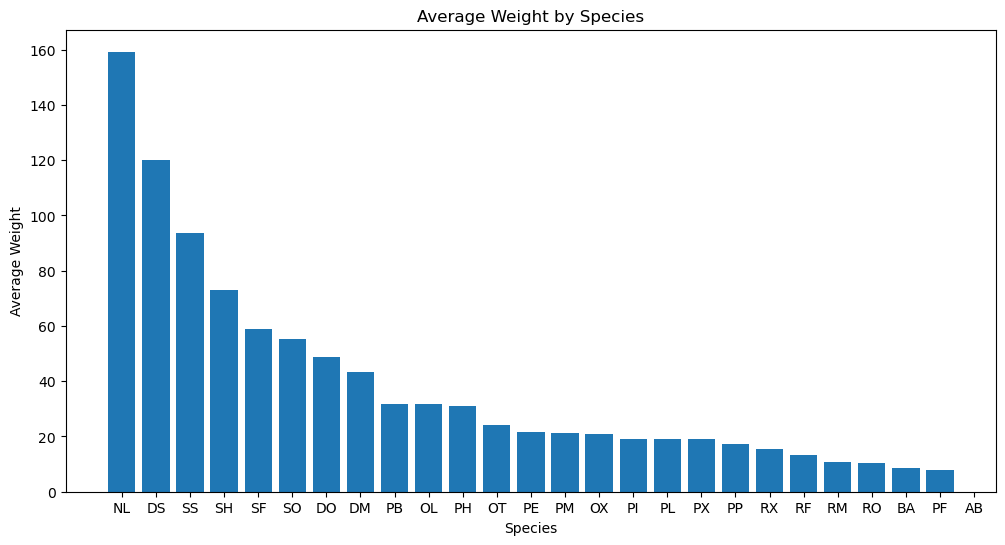

In [21]:
# Average Weight by Species
# ==========================================

avg_species_weight = (
    df.groupby('species_id')['weight']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    avg_species_weight.index,
    avg_species_weight.values
)

plt.xlabel('Species')
plt.ylabel('Average Weight')
plt.title('Average Weight by Species')

plt.savefig('./images/average_weight_by_species.png')

plt.show()

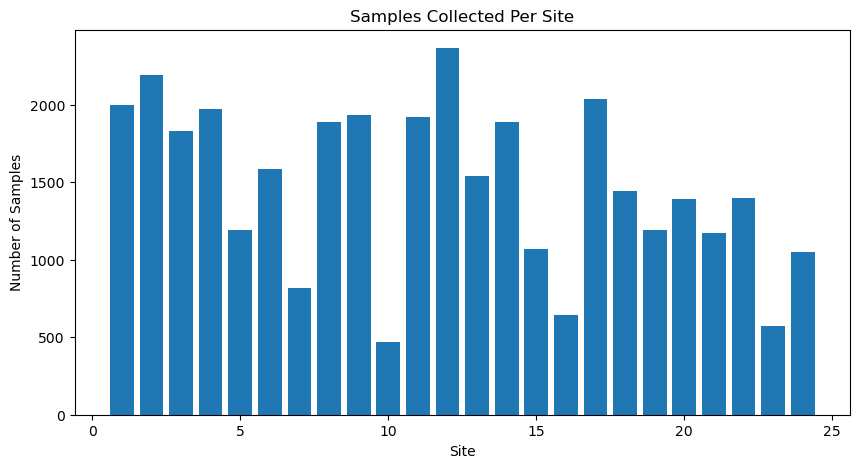

In [23]:
# Samples Per Site
# ==========================================

site_counts = df['plot_id'].value_counts()

plt.figure(figsize=(10, 5))

plt.bar(site_counts.index, site_counts.values)

plt.xlabel('Site')
plt.ylabel('Number of Samples')
plt.title('Samples Collected Per Site')

plt.savefig('./images/samples_per_site.png')

plt.show()

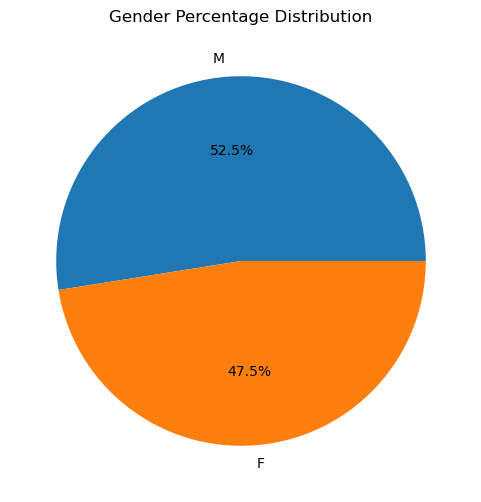

In [25]:
# Gender Percentage Distribution
# ==========================================

sex_count = df['sex'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    sex_count.values,
    labels=sex_count.index,
    autopct='%1.1f%%'
)

plt.title('Gender Percentage Distribution')

plt.savefig('./images/gender_percentage_distribution.png')

plt.show()